###imports

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from scipy.optimize import minimize
from scipy.stats import multivariate_normal
from scipy.linalg import inv
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from copy import deepcopy
from google.colab import files

In [2]:
import random
SEED = 42  # или любое другое число

np.random.seed(SEED)
random.seed(SEED)  # если используете random из стандартной библиотеки

In [3]:
# Установка глобальных параметров шрифта
plt.rcParams['font.size'] = 14          # Размер основного шрифта
plt.rcParams['axes.titlesize'] = 16     # Размер заголовка
plt.rcParams['axes.labelsize'] = 14     # Размер подписей осей
plt.rcParams['xtick.labelsize'] = 12    # Размер цифр на оси X
plt.rcParams['ytick.labelsize'] = 12    # Размер цифр на оси Y
plt.rcParams['legend.fontsize'] = 12    # Размер шрифта легенды

In [4]:
"""
from itertools import product
from copy import deepcopy
import torch.optim as optim
import itertools
"""

'\nfrom itertools import product\nfrom copy import deepcopy\nimport torch.optim as optim\nimport itertools\n'

In [5]:
"""
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
"""

'\n!pip uninstall torch torchvision torchaudio -y\n!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu\n'

# Функциии

## фильтры

In [ ]:
# Фильтр Калмана
def Kalman_filter(zs, x0, P0, F, H, Q, R, Ge, dt=0.1, Ksi_U = None):
  dim = x0.shape[0]
  x=np.reshape(x0, (dim,1))

  if Ksi_U.all() == None:
    Ksi_U = np.zeros((zs.shape[0],dim, 1))

  xf = []

  P=P0.copy()
  t=0
  Ksi_U = Ksi_U.reshape(((zs.shape[0],dim, 1)))
  for z in zs:
      # predict
      x = F @ x + Ksi_U[t]
      P = F @ P @ F.T + Ge @ Q @ Ge.T

      #update
      S = H @ P @ H.T + R
      K = P @ H.T @ inv(S)
      epsi = z - H @ x
      x += K @ epsi
      P = P - K @ H @ P

      xf.append(x.reshape(dim))
      t+=1
  return xf

In [ ]:
def Ahlagi_Zhou_Huang_filter(zs, x0, P0, F, H, Q, R, Ge, alpha, Ksi_U = None, dt=0.1, plot_qr=False):
  dim = x0.shape[0]
  x=np.reshape(x0, (dim,1))
  if Ksi_U.all() == None:
    Ksi_U = np.zeros((zs.shape[0],dim, 1))
  Ksi_U = Ksi_U.reshape(((zs.shape[0],dim, 1)))

  N = zs.shape[0]
  P = P0.copy()
  Qs = Q.copy()
  Rs = R.copy()

  arr_Q = np.zeros((N, Q.shape[0], Q.shape[0]))
  arr_R = np.zeros((N, 1, 1))
  xf_filt = []
  t=0


  for z in zs:
      arr_Q[t] = Qs
      arr_R[t] = Rs

      # predict
      x2 = F @ x + Ksi_U[t]
      P2 = F @ P @ F.T + Ge @ Qs @ Ge.T

      #update
      S = H @ P2 @ H.T + Rs
      K = P2 @ H.T @ inv(S)
      epsi = z - H @ x2
      x =x2 + K @ epsi
      P = P2 - K @ H @ P2

      #adaptation
      d = (z - H @ x) #[:, np.newaxis] #бред
      Rs = alpha * Rs + (1 - alpha) * (d @ d.T + H @ P2 @ H.T)

      G = inv(Ge.T @ Ge) @ Ge.T
      Qs = alpha * Qs + (1 - alpha) * (G @ (K @ epsi @ epsi.T @ K.T) @ G.T)

      t+=1

      xf_filt.append(np.reshape(x, (dim)))

  if plot_qr:
    fig, axs = plt.subplots(1, 2, figsize=(15, 10))
    fig.suptitle('Анализ параметров фильтра Ахлаги...', fontsize=16)
    for i in range(dim):
        axs[1, 0].plot(arr_Q[:, i, i], label=f'Q[{i},{i}]')
    axs[1, 0].set_title('Диагональные элементы Q (ковариация процессного шума)')
    axs[1, 0].set_xlabel('Временной шаг')
    axs[1, 0].set_ylabel('Значение')
    axs[1, 0].legend()
    axs[1, 0].grid(True)

    axs[1, 1].plot(arr_R[:, 0], 'm-', label='R')
    axs[1, 1].set_title('Скаляр R (ковариация шума измерений)')
    axs[1, 1].set_xlabel('Временной шаг')
    axs[1, 1].set_ylabel('Значение')
    axs[1, 1].legend()
    axs[1, 1].grid(True)
    plt.tight_layout()
    plt.show()

    # Отдельный график для всех компонент arr_Q
    plt.figure(figsize=(14, 8))
    colors = plt.cm.tab10.colors
    for i in range(dim):
        for j in range(dim):
            plt.plot(arr_Q[:, i, j],
                    color=colors[i*dim + j],
                    linestyle='-',
                    linewidth=1.5,
                    label=f'Q[{i},{j}]')

    plt.title('Все компоненты матрицы Q (ковариация процессного шума)', fontsize=14)
    plt.xlabel('Временной шаг', fontsize=12)
    plt.ylabel('Значение', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(bbox_to_anchor=(1.05, 1),
              loc='upper left',
              borderaxespad=0.,
              fontsize=10)
    plt.tight_layout()
    plt.show()

  return xf_filt

In [ ]:
# Фильтр Sage-Husa
#Есть ли смысл если у нас B=G=единичной?
def Sage_Husa_filter_expend(zs, x0, P0, F, H, Q, R,
                     B = np.eye(3), b = 0.998, dt=0.1, plot_qr=False):
  G = inv(B.T @ B) @ B.T
  k = x0.shape[0]
  q = np.zeros((k, 1))
  r =np.zeros(1)
  # 0<b<1 (generally between 0.995 and 0.999)
  d = 1.0

  x=np.reshape(x0,(3,1))
  P=P0.copy()
  Qs = Q.copy()  # Матрица ковариации шума процесса (3x3)
  Rs = R.copy()        # Матрица ковариации шума измерений (3x3)

  arr_q = np.zeros((zs.shape[0], k))
  arr_r = np.zeros((zs.shape[0], 1))
  arr_Q = np.zeros((zs.shape[0], k, k))
  arr_R = np.zeros((zs.shape[0], 1))

  xf_sage = []
  t=0

  for z in zs:
      arr_q[t] = q[:, 0]
      arr_r[t] = r
      arr_Q[t] = Qs
      arr_R[t] = Rs

      # predict
      x1 = x.copy()
      x2 = F @ x  + B @ q
      P1 = P.copy()
      P2 = F @ P @ F.T + B @ Qs @ B.T

      #update
      S = H @ P2 @ H.T + Rs
      K = P2 @ H.T @ inv(S)
      epsi = z - H @ x2 - r
      x =x2 + K @ epsi
      P = P2 - K @ H @ P2


      #t+=1 #лучшая версия
      d = (1-b)/(1-b**(t+1))

      """
      # Для Rs (если z - скаляр, ваш код работает; если вектор - нужно доработать)
      Rs = (1-d)*Rs + d*(epsi @ epsi.T - H @ P2 @ H.T)
      Rs = (Rs + Rs.T) / 2  # Ensure symmetry
      Rs = np.clip(Rs, a_min=1e-6, a_max=None)  # Avoid negative values
      # Для Qs (аналогично)
      Qs = (1-d)*Qs + d * (K @ epsi @ epsi.T @ K.T + P - F @ P1 @ F.T)
      Qs = (Qs + Qs.T) / 2
      Qs = np.clip(Qs, a_min=1e-6, a_max=None)
      """

      q = (1-d)*q + d*(G @ (x - F @ x1))
      r = (1-d)*r + d*(z- H @ x2)
      Rs =(1-d)*Rs + d*(epsi @ epsi.T - H @ P2 @ H.T)
      Qs = (1-d)*Qs + d * (G @ (K @ epsi @ epsi.T @ K.T + P - F @ P1 @ F.T) @ G.T)
      t+=1

      xf_sage.append(np.reshape(x, (3)))

  if plot_qr:
    # Предположим, у вас уже есть данные:
    # arr_q, arr_r, arr_Q, arr_R - сформированы как в вашем коде

    # Создаем фигуру с 4 субплотами
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Анализ параметров фильтра Калмана', fontsize=16)

    # 1. График для arr_q (3 компоненты)
    for i in range(3):
        axs[0, 0].plot(arr_q[:, i], label=f'Компонента q[{i}]')
    axs[0, 0].set_title('Вектор q')
    axs[0, 0].set_xlabel('Временной шаг')
    axs[0, 0].set_ylabel('Значение')
    axs[0, 0].legend()
    axs[0, 0].grid(True)

    # 2. График для arr_r
    axs[0, 1].plot(arr_r[:, 0], 'r-', label='r')
    axs[0, 1].set_title('Скаляр r')
    axs[0, 1].set_xlabel('Временной шаг')
    axs[0, 1].set_ylabel('Значение')
    axs[0, 1].legend()
    axs[0, 1].grid(True)

    # 3. График для arr_Q (диагональные элементы)
    for i in range(3):
        axs[1, 0].plot(arr_Q[:, i, i], label=f'Q[{i},{i}]')
    axs[1, 0].set_title('Диагональные элементы Q (ковариация процессного шума)')
    axs[1, 0].set_xlabel('Временной шаг')
    axs[1, 0].set_ylabel('Значение')
    axs[1, 0].legend()
    axs[1, 0].grid(True)

    # 4. График для arr_R
    axs[1, 1].plot(arr_R[:, 0], 'm-', label='R')
    axs[1, 1].set_title('Скаляр R (ковариация шума измерений)')
    axs[1, 1].set_xlabel('Временной шаг')
    axs[1, 1].set_ylabel('Значение')
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    # Регулировка отступов
    plt.tight_layout()
    # Сохранение графиков
    #plt.savefig('kalman_parameters.png', dpi=300)
    plt.show()


    # Отдельный график для всех компонент arr_Q
    plt.figure(figsize=(14, 8))
    colors = plt.cm.tab10.colors  # Палитра цветов

    # Рисуем все 9 компонент матрицы Q
    for i in range(3):
        for j in range(3):
            plt.plot(arr_Q[:, i, j],
                    color=colors[i*3 + j],
                    linestyle='-',
                    linewidth=1.5,
                    label=f'Q[{i},{j}]')

    plt.title('Все компоненты матрицы Q (ковариация процессного шума)', fontsize=14)
    plt.xlabel('Временной шаг', fontsize=12)
    plt.ylabel('Значение', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

    # Размещаем легенду вне графика
    plt.legend(bbox_to_anchor=(1.05, 1),
              loc='upper left',
              borderaxespad=0.,
              fontsize=10)

    plt.tight_layout()
    plt.savefig('Q_matrix_all_components.png', dpi=300, bbox_inches='tight')
    plt.show()

  return xf_sage

In [ ]:
def Sage_Husa_filter_classic(zs, x0, P0, F, H, Q, R, Gamma, b=0.998, plot_qr=False):
    k = x0.shape[0]
    x = np.reshape(x0, (k,1))
    P = P0.copy()
    Qs = Q.copy()
    Rs = R.copy()

    arr_Q = np.zeros((zs.shape[0], k, k))
    arr_R = np.zeros((zs.shape[0], 1))

    xf_sage = []
    t = 0

    for z in zs:
        arr_Q[t] = Qs
        arr_R[t] = Rs

        # predict
        x_pred = F @ x
        P_pred = F @ P @ F.T + Gamma @ Qs @ Gamma.T

        # update
        S = H @ P_pred @ H.T + Rs
        K = P_pred @ H.T @ np.linalg.inv(S)
        epsilon = z - H @ x_pred
        x = x_pred + K @ epsilon
        P = P_pred - K @ H @ P_pred

        # adaptation
        tau = (1 - b) / (1 - b**(t+1)) if t > 0 else 1.0  # avoid division by zero at t=0

        # R
        Rs = (1 - tau) * Rs + tau * (epsilon @ epsilon.T - H @ P_pred @ H.T)

        # G
        G = np.linalg.inv(Gamma.T @ Gamma) @ Gamma.T

        # Q
        innovation_term = K @ epsilon @ epsilon.T @ K.T + P - F @ P @ F.T
        Qs = (1 - tau) * Qs + tau * (G @ innovation_term @ G.T)

        t += 1
        xf_sage.append(np.reshape(x, (k)))

    return xf_sage

## визуал и armse

In [ ]:
def calculate_ARMSE_n_dim(true_states, fil_states):
    errors = true_states - fil_states  # форма: (M, N, x_dim)

    armse_i = np.sqrt(np.mean(errors**2, axis=(0, 1)))

    ARMSE = np.linalg.norm(armse_i)  # √(Σ ARMSE_i²)

    return ARMSE

def print_result_filt_ARMSE(true_x, true_states, y_measure, fil_states, num_Xi, fl_true_x = False):

    M = true_x.shape[0]
    N = true_x.shape[1]
    x_dim = true_x.shape[-1]

    err_true = calculate_ARMSE_n_dim(true_x[:, :, num_Xi], fil_states[:, :, num_Xi])
    err_state = calculate_ARMSE_n_dim(true_states[:, :, num_Xi], fil_states[:, :, num_Xi])
    err_measure = calculate_ARMSE_n_dim(y_measure[:, :, 0], fil_states[:, :, num_Xi])

    #err_Milutin = calculate_ARMSE_n_dim(y_measure[:, :, num_Xi], fil_states[:, :, num_Xi])

    print(f"Компонента {num_Xi}")
    if fl_true_x:
      print("Clear x & Filt x:                {:.4f}".format(err_true))
    print("State x & Filt x:               {:.4f}".format(err_state))
    print("Measure y x & Filt x:               {:.4f}".format(err_measure))


    err_true = calculate_ARMSE_n_dim(true_x[:, :, :], fil_states[:, :, :])
    err_state = calculate_ARMSE_n_dim(true_states[:, :, :], fil_states[:, :, :])
    print(f"Все компоненты")
    if fl_true_x:
      print("Clear x & Filt x:                {:.4f}".format(err_true))
    print("State x & Filt x:               {:.4f}".format(err_state))

    return err_true, err_state


In [ ]:
def plot_three_curves(y_true, y_m, x_akf, x_akf_enn, m=30, title="Сравнение траекторий",
                      labels=("Истинное значение", "Измерения", "AKF", "AKF+ENN"),
                      xlabel="Время (номер шага)", ylabel="Значение"):
    # Проверка размерностей
    if not (len(y_m) == len(x_akf) == len(x_akf_enn)):
        raise ValueError("Все входные массивы должны иметь одинаковую длину.")

    n = len(y_m)
    time_axis = np.arange(n)

    plt.figure(figsize=(12, 6))
    plt.plot(time_axis, y_m,       'o-',  markersize=3, linewidth=1.5, label=labels[1], alpha= 0.3)
    plt.plot(time_axis, x_akf,     's-',  markersize=2, linewidth=2,   label=labels[2])
    plt.plot(time_axis, x_akf_enn, '^-',  markersize=2, linewidth=2,   label=labels[3])
    plt.plot(time_axis, y_true,    'r--',  markersize=3, linewidth=1.5, label=labels[0], alpha= 0.7)


    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    #plt.show()


    time_axis = np.arange(m)
    plt.figure(figsize=(12, 6))
    plt.plot(time_axis, y_m[:m],       'o-',  markersize=3, linewidth=1.5, label=labels[1], alpha= 0.3)
    plt.plot(time_axis, x_akf[:m],     's-',  markersize=2, linewidth=2,   label=labels[2])
    plt.plot(time_axis, x_akf_enn[:m], '^-',  markersize=2, linewidth=2,   label=labels[3])
    plt.plot(time_axis, y_true[:m],    'r--',  markersize=3, linewidth=1.5, label=labels[0], alpha= 0.7)


    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_model2_results(states_history, x_true_arr, y, N, T=0.1):
    """Визуализация результатов моделирования"""
    time = np.arange(N) * T

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # График 1: Угловое положение (x1)
    axes[0, 0].plot(time, states_history[:, 0], 'b-', alpha=0.7, label='Модель с шумом')
    axes[0, 0].plot(time, x_true_arr[:, 0], 'g-', label='Истинное значение')
    axes[0, 0].set_title('Угловое положение (x1)')
    axes[0, 0].set_xlabel('Время')
    axes[0, 0].set_ylabel('Значение')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # График 2: Угловая скорость (x2)
    axes[0, 1].plot(time, states_history[:, 1], 'b-', alpha=0.7, label='Модель с шумом')
    axes[0, 1].plot(time, x_true_arr[:, 1], 'g-', label='Истинное значение')
    axes[0, 1].set_title('Угловая скорость (x2)')
    axes[0, 1].set_xlabel('Время')
    axes[0, 1].set_ylabel('Значение')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # График 3: Измерения
    axes[1, 0].plot(time, y, 'r-', alpha=0.7, label='Измерения')
    axes[1, 0].plot(time, x_true_arr[:, 0], 'g-', label='Истинное значение')
    axes[1, 0].set_title('Измерения углового положения')
    axes[1, 0].set_xlabel('Время')
    axes[1, 0].set_ylabel('Значение')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # График 4: Шумы
    axes[1, 1].plot(time, states_history[:, 0] - x_true_arr[:, 0], 'orange', label='Ошибка состояния')
    axes[1, 1].plot(time, y[:,0] - x_true_arr[:, 0], 'purple', alpha=0.7, label='Ошибка измерений')
    axes[1, 1].set_title('Ошибки модели для х1 - положения')
    axes[1, 1].set_xlabel('Время')
    axes[1, 1].set_ylabel('Ошибка')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

## модели

In [ ]:
def model_2_angular_pos(x0, P0, Q, R, F, S, N, plot_fl=False):
    """
    Генерация данных для системы с шумами

    Parameters:
    x0 : array_like - начальное матожидание состояния
    P0 : array_like - начальная ковариационная матрица состояния
    Q : float - дисперсия шума процесса
    R : float - дисперсия шума измерений
    F : array_like - матрица перехода состояния
    S : array_like - вектор управления
    B : array_like - вектор шума процесса
    N : int - количество шагов
    """
    dt = 0.1
    # Размерности
    n = P0.shape[0]  # размерность состояния = 2
    S = S.reshape(n)

    # Генерация шумов
    w = np.random.multivariate_normal(np.zeros(n), Q, N)  # shape (N, 2)
    v = np.random.normal(0, np.sqrt(R[0,0]), N)  # shape (N,)

    # Инициализация массивов
    states_history = np.zeros((N, n))
    x_true_arr = np.zeros((N, n))
    y = np.zeros((N,1))

    # Начальное состояние - случайное из распределения N(x0, P0)
    X_cur_true = x0.copy()
    X_current = np.random.multivariate_normal(x0, P0) #.reshape(-1, 1) #x0

    t = dt * np.arange(N)
    u = 3 + 2 * np.sin(4 * np.pi * t)

    for j in range(N):
        X_cur_true = F @ X_cur_true + S * u[j]
        x_true_arr[j] = X_cur_true

        X_current = F @ X_current + S * u[j] + w[j] #.reshape(-1, 1)
        states_history[j] = X_current

        y[j] = X_current[0] + v[j]

    if plot_fl:
        plot_model2_results(states_history, x_true_arr, y, N)

    return x_true_arr, states_history, y

In [ ]:
def model_1_speed(x0, P0, Q, R, N, plot_fl=False):
    dt = 0.1
    n = P0.shape[1]  # =3 (размерность состояния)

    X_cut_true = x0
    X_cur = np.random.multivariate_normal(x0, P0)
    F = np.array([[1, dt, (dt**2)/2],
                  [0, 1, dt],
                  [0, 0, 1]])

    y = np.zeros((N, 1))
    x_true_arr = np.zeros((N,n))
    states_history = np.zeros((N, n))

    # Генерация шумов
    w = np.random.multivariate_normal(np.zeros(n), Q, N)
    v = np.random.normal(0, np.sqrt(R[0,0]), N)

    # В модели генерации:
    #w = np.random.normal(0, np.sqrt(Q[0,0]), N)  # скалярный шум


    for j in range(N):
        X_cut_true = F @ X_cut_true
        x_true_arr[j] = X_cut_true

        X_cur = F @ X_cur + w[j]
        #X_cur = F @ X_cur + Gamma.flatten() * w[j]
        states_history[j] = X_cur

        current_measurement = X_cur[1] + v[j]
        y[j] = current_measurement


    if plot_fl:
        time = np.arange(N) * dt

        plt.figure(figsize=(12, 9))
        # График всех компонент состояния вместе
        plt.subplot(2, 2, 1)
        plt.plot(time, states_history[:, 0], label='Position (x1)')
        plt.plot(time, y, label='Velocity y - result')
        plt.plot(time, states_history[:, 2], label='Acceleration (x3)')
        plt.title('All State Components')
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True)

        # Графики компонент по отдельности
        plt.subplot(2, 2, 2)
        plt.plot(time, states_history[:, 0], 'r')
        plt.plot(time, x_true_arr[:, 0], 'g')
        plt.title('Position (x1)')
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.grid(True)

        plt.subplot(2, 2, 3)
        plt.plot(time, y, 'r')
        plt.plot(time, x_true_arr[:, 1], 'g')
        plt.title('Velocity y - result')
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.grid(True)

        plt.subplot(2, 2, 4)
        plt.plot(time, states_history[:, 2], 'r')
        plt.plot(time, x_true_arr[:, 2], 'g')
        plt.title('Acceleration (x3)')
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.grid(True)

        plt.tight_layout()
        plt.show()


    return x_true_arr, states_history, y

## enn

In [ ]:
def rmse_in_time(y1, y2):
  return np.sqrt((((y1 - y2)**2).sum(axis=0)) / y1.shape[0])

In [ ]:
def result_enn_rmse(true_x, true_states, y_measure,
                    fil_states, predictions, y_cec, Q_new, R_new, num_xi, fl_train=True):

  y_enn = predictions + y_cec[:,:,1]
  x_start = true_x.shape[1] - y_enn.shape[1]
  end = true_x.shape[0]
  st = end-y_enn.shape[0]
  if fl_train:
    st = 0
    end = y_enn.shape[0]
  e1 = np.sqrt(mean_squared_error(true_x[st:end, x_start:, num_xi], true_states[st:end, x_start:, num_xi]))
  e2 = np.sqrt(mean_squared_error(true_x[st:end, x_start:, num_xi], y_measure[st:end, x_start:, 0]))
  e3 = np.sqrt(mean_squared_error(true_x[st:end, x_start:, num_xi], fil_states[st:end, x_start:, num_xi]))
  e4 = np.sqrt(mean_squared_error(true_x[st:end, x_start:, num_xi], y_enn))


  print('\n', true_x[st:end, 2:, num_xi].shape)
  print("True Vs Measure y    ", e2)
  print("True Vs AKF        ", e3)
  print("True Vs ENN          ", e4)

  rmse_row1 = [e2, e3, e4]

  e1 = np.sqrt(mean_squared_error(fil_states[st:end, x_start:, num_xi], y_measure[st:end, x_start:, 0]))
  e2 = np.sqrt(mean_squared_error(y_enn, y_measure[st:end, x_start:, 0]))
  print("Measure y Vs AKF      ", e1)
  print("Measure y Vs ENN      ", e2)
  rmse_row2 = [e1, e2]
  e2 = np.sqrt(mean_squared_error(true_states[st:end, x_start:, num_xi], y_measure[st:end, x_start:, 0]))
  e3 = np.sqrt(mean_squared_error(true_states[st:end, x_start:, num_xi], fil_states[st:end, x_start:, num_xi]))
  e4 = np.sqrt(mean_squared_error(true_states[st:end, x_start:, num_xi], y_enn))
  #print("\nState X Vs Measure y    ", e2)
  #print("State X Vs AKF     ", e3)
  #print("State X Vs Kalman     ", e5)
  #print("State X Vs ENN          ", e4)

  return y_enn, rmse_row1, rmse_row2

In [ ]:
class SequenceRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(SequenceRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers,
                         batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size, 1)  # Каждый шаг → 1 число

    def forward(self, x):
        # x shape: (batch_size, 300, 3)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.rnn(x, h0)  # out shape: (batch_size, 300, hidden_size)
        out = self.fc(out)  # shape: (batch_size, 300, 1)
        return out
    def predict(self, x):
        # Переводим модель в режим оценки
        self.eval()

        # Автоматическое преобразование входных данных
        if not isinstance(x, torch.Tensor):
            x = torch.FloatTensor(x)

        # Добавляем размерность батча если нужно
        if x.dim() == 2:
            x = x.unsqueeze(0)

        # Вычисление предсказания без вычисления градиентов
        with torch.no_grad():
            prediction = self.forward(x)

        return prediction.squeeze().numpy()  # Возвращаем numpy array

# Main Линейные модели

## параметры

In [ ]:
N = 300
all_seq_s = 80
all_seq_s2 = 20
dt = 0.1

In [ ]:
num_case = 3

## Model 2 - Antena

In [ ]:
dim_X = 2  #размерность X
num_Xi = 0 #индекс целевой компоненты вектора состояния

F = np.array([[1, 0.080156],
              [0, 0.631283]])
S = np.array([[0.003395], [0.063083]])
H = np.array([[1, 0]])
Ge = np.eye(dim_X)

x0 = np.array([0., 0.])
P0 = np.diag([0.01, 0.01])
Q = np.array([[2e-5, 3e-4],
              [3e-4, 6e-3]])
R = np.array([[1e-6]])

Q = np.array([[0.001, 0.0],
              [0.0, 0.01]])
R = np.array([[0.1]])

t = dt * np.arange(N)

u = 3 + 2 * np.sin(4 * np.pi * t)
S_u = np.zeros((N,2))
S_temp = S.reshape(2)
for i in range(N):
  S_u[i] = S_temp * u[i]

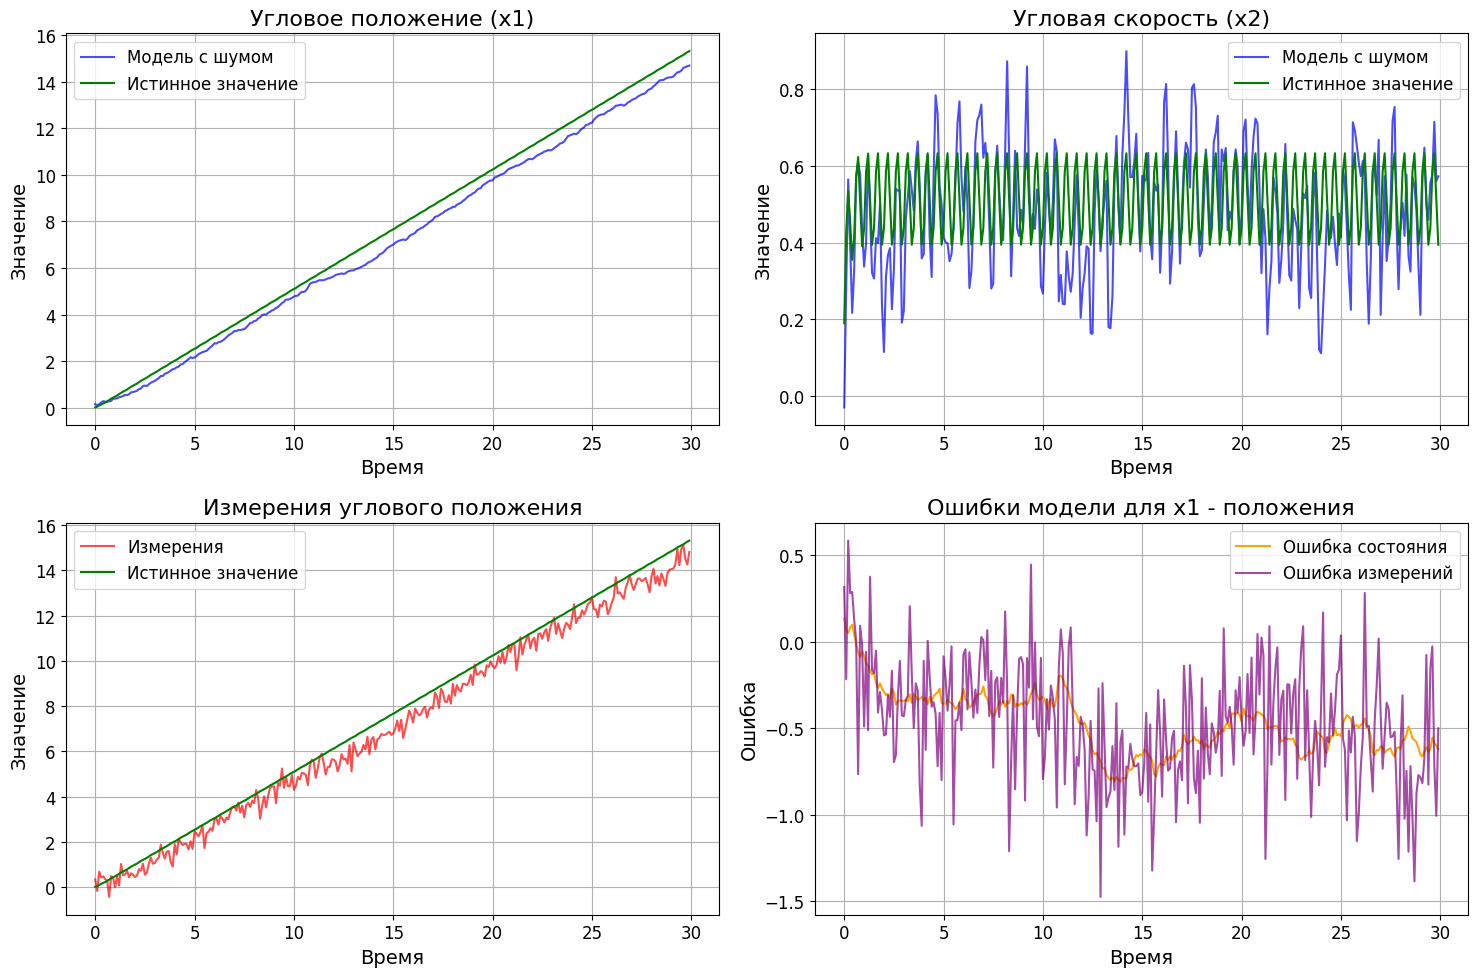

In [ ]:
clear_x, unfil_x, zs = model_2_angular_pos(x0, P0, Q, R, F, S, N, plot_fl=True)

In [ ]:
x_true = np.zeros((all_seq_s, N, dim_X))
x_noise = np.zeros((all_seq_s, N, dim_X))
y_measure1 = np.zeros((all_seq_s, N, 1))
for i in range(all_seq_s):
  clear_x, unfil_x, zs = model_2_angular_pos(x0, P0, Q, R, F, S, N)
  x_true[i, :, :] = clear_x
  x_noise[i, :, :] = unfil_x
  y_measure1[i, :, :] = zs

In [ ]:
# Данные тест
x_true2 = np.zeros((all_seq_s2, N, dim_X))
x_noise2 = np.zeros((all_seq_s2, N, dim_X))
y_measure2 = np.zeros((all_seq_s2, N, 1))
for i in range(all_seq_s2):
  clear_x, unfil_x, zs = model_2_angular_pos(x0, P0, Q, R, F, S, N)
  x_true2[i, :, :] = clear_x
  x_noise2[i, :, :] = unfil_x
  y_measure2[i, :, :] = zs

#таблицы для сохранения
columns = ['Q, R', 'Измеренный y', 'Ahlagi', 'AKF+ENN', 'alpha', 'train_loss', 'val_loss', 'lr', 'hidden_size']
df_true = pd.DataFrame(columns=columns)

#columns = ['Q, R', 'y&Kalman', 'y&Ahlagi', 'y&ENN']
#df_measure = pd.DataFrame(columns=columns)

In [ ]:
best_results_antenna = [
    {'case': 'Q/100, R/100',  'Q': Q / 100,  'R': R / 100,  'best_alpha': 0.999},
    {'case': 'Q*100, R*100',  'Q': Q * 100,  'R': R * 100,  'best_alpha': 0.999},
    {'case': 'Q/100, R*100',  'Q': Q / 100,  'R': R * 100,  'best_alpha': 0.999},
    {'case': 'Q*100, R/100',  'Q': Q * 100,  'R': R / 100,  'best_alpha': 0.999},
]


#  для 1 компоненты (true 6)
best_results_antenna = [
    {'case': 'Q;1000, R;1000',  'Q': Q / 1000,  'R': R / 1000,  'best_alpha': 0.15},
    {'case': 'Qx10000, Rx10000',  'Q': Q * 1000,  'R': R * 1000,  'best_alpha': 0.12},
    {'case': 'Q;1000, Rx1000',  'Q': Q / 1000,  'R': R * 1000,  'best_alpha': 0.15},
    {'case': 'Qx1000, R;1000',  'Q': Q * 1000,  'R': R / 1000,  'best_alpha': 0.12},
]

#  для 1 компоненты (true 6)
best_results_antenna = [
    {'case': 'Q;100, R;100',  'Q': Q / 100,  'R': R / 100,  'best_alpha': 0.15},
    {'case': 'Qx100, Rx100',  'Q': Q * 100,  'R': R * 100,  'best_alpha': 0.14},
    {'case': 'Q;100, Rx100',  'Q': Q / 100,  'R': R * 100,  'best_alpha': 0.15},
    {'case': 'Qx100, R;100',  'Q': Q * 100,  'R': R / 100,  'best_alpha': 0.14},
]

Q_new = best_results_antenna[num_case]['Q']
R_new = best_results_antenna[num_case]['R']
best_alpha = best_results_antenna[num_case]['best_alpha']
best_results = best_results_antenna

## Model 1 - Speed

In [ ]:
dim_X = 3
num_Xi = 1

x0 = np.array([0., 0., 1.])
Q = np.diag([0.01, 0.001, 0.0001])
P0 = np.diag([0.01, 0.001, 0.0001])
R = np.array([[1.0]])

F = np.array([[1., dt, (dt**2)/2],
              [0.,  1., dt],
              [0., 0., 1.]])
H = np.array([[0, 1, 0]])
Ge = np.eye(dim_X)


S_u = np.zeros((N,dim_X))

# Параметры
#q_acc = 0.0001  # дисперсия ускорения
#Q = np.array([[q_acc]])  # скаляр

# Матрица Gamma
Gamma = np.array([[0.5 * dt**2],
                  [dt],
                  [1.0]])  # (3,1)

In [ ]:
x_true = np.zeros((all_seq_s, N, dim_X))
x_noise = np.zeros((all_seq_s, N, dim_X))
y_measure1 = np.zeros((all_seq_s, N, 1))
for i in range(all_seq_s):
  clear_x, unfil_x, zs = model_1_speed(x0, P0, Q, R, N)
  x_true[i, :, :] = clear_x
  x_noise[i, :, :] = unfil_x
  y_measure1[i, :, :] = zs

In [ ]:
# Данные тест
x_true2 = np.zeros((all_seq_s2, N, dim_X))
x_noise2 = np.zeros((all_seq_s2, N, dim_X))
y_measure2 = np.zeros((all_seq_s2, N, 1))
for i in range(all_seq_s2):
  clear_x, unfil_x, zs = model_1_speed(x0, P0, Q, R, N)
  x_true2[i, :, :] = clear_x
  x_noise2[i, :, :] = unfil_x
  y_measure2[i, :, :] = zs

#таблицы для сохранения
columns = ['Q, R', 'Измеренный y', 'Ahlagi', 'AKF+ENN', 'alpha', 'train_loss', 'val_loss', 'lr', 'hidden_size']
df_true = pd.DataFrame(columns=columns)

#columns = ['Q, R', 'y&Kalman', 'y&Ahlagi', 'y&ENN']
#df_measure = pd.DataFrame(columns=columns)

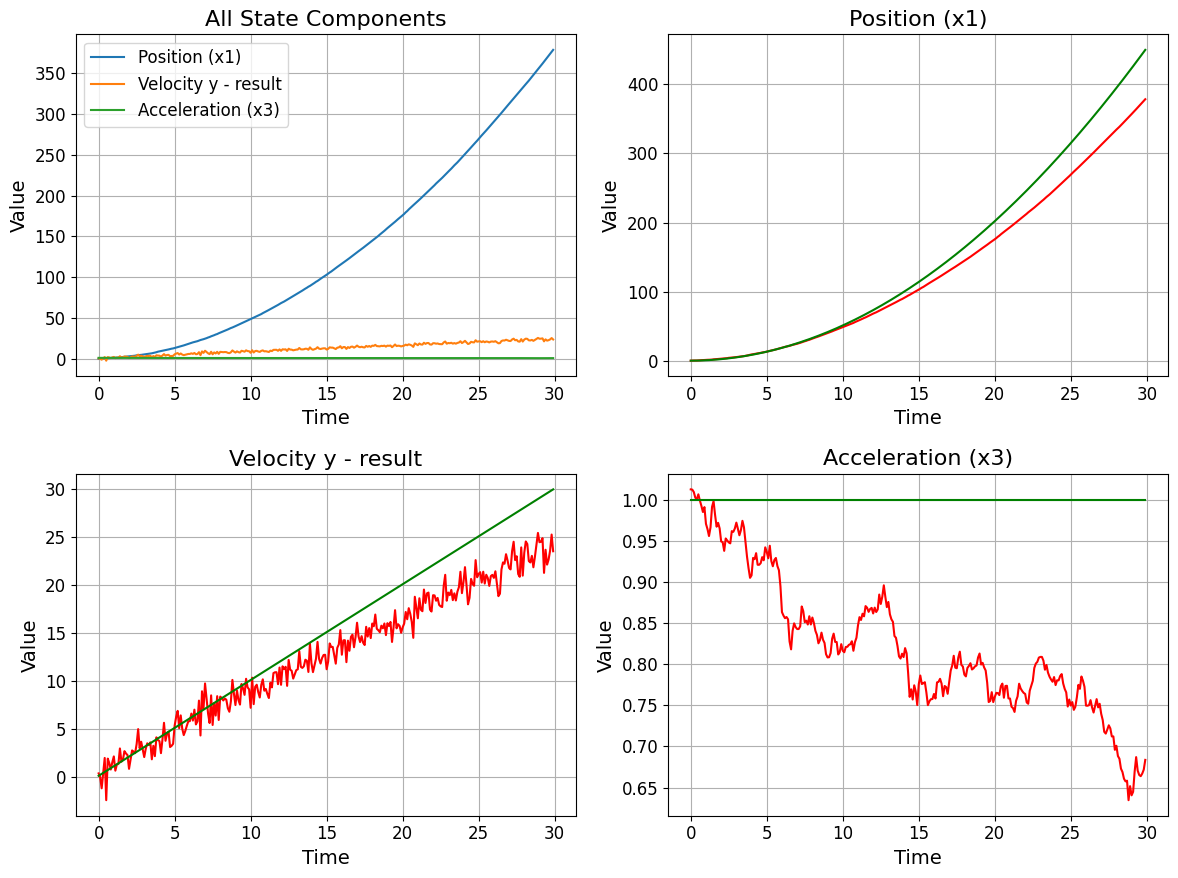

In [ ]:
ans = model_1_speed(x0, P0, Q, R, N, plot_fl=True)

In [ ]:
# для 1 компоненты скорости (state)
best_results_speed = [
    {'case': 'Q/100, R/100',  'Q': Q / 100,  'R': R / 100,  'best_alpha': 0.870},
    {'case': 'Q*100, R*100',  'Q': Q * 100,  'R': R * 100,  'best_alpha': 0.980},
    {'case': 'Q/100, R*100',  'Q': Q / 100,  'R': R * 100,  'best_alpha': 0.730},
    {'case': 'Q*100, R/100',  'Q': Q * 100,  'R': R / 100,  'best_alpha': 0.760},
]

# для всех компонент (state)
best_results_speed = [
    {'case': 'Q;100, R;100',  'Q': Q / 100,  'R': R / 100,  'best_alpha': 0.998},
    {'case': 'Qx100, Rx100',  'Q': Q * 100,  'R': R * 100,  'best_alpha': 0.995},
    {'case': 'Q;100, Rx100',  'Q': Q / 100,  'R': R * 100,  'best_alpha': 0.947},
    {'case': 'Qx100, R;100',  'Q': Q * 100,  'R': R / 100,  'best_alpha': 0.959},
]

# для 1 компоненты скорости (true 6)
best_results_speed = [
    {'case': 'Q;100, R;100',  'Q': Q / 100,  'R': R / 100,  'best_alpha': 0.96},
    {'case': 'Qx100, Rx100',  'Q': Q * 100,  'R': R * 100,  'best_alpha': 0.98},
    {'case': 'Q;100, Rx100',  'Q': Q / 100,  'R': R * 100,  'best_alpha': 0.98},
    {'case': 'Qx100, R;100',  'Q': Q * 100,  'R': R / 100,  'best_alpha': 0.73},
]

Q_new = best_results_speed[num_case]['Q']
R_new = best_results_speed[num_case]['R']
best_alpha = best_results_speed[num_case]['best_alpha']
best_results = best_results_speed

## Параметры для фильтра



Количество запусков для каждого параметра: 15
Суммарно: 1470 * 4
Обработка: Q/100, R/100
Обработка: Q*100, R*100
Обработка: Q/100, R*100
Обработка: Q*100, R/100


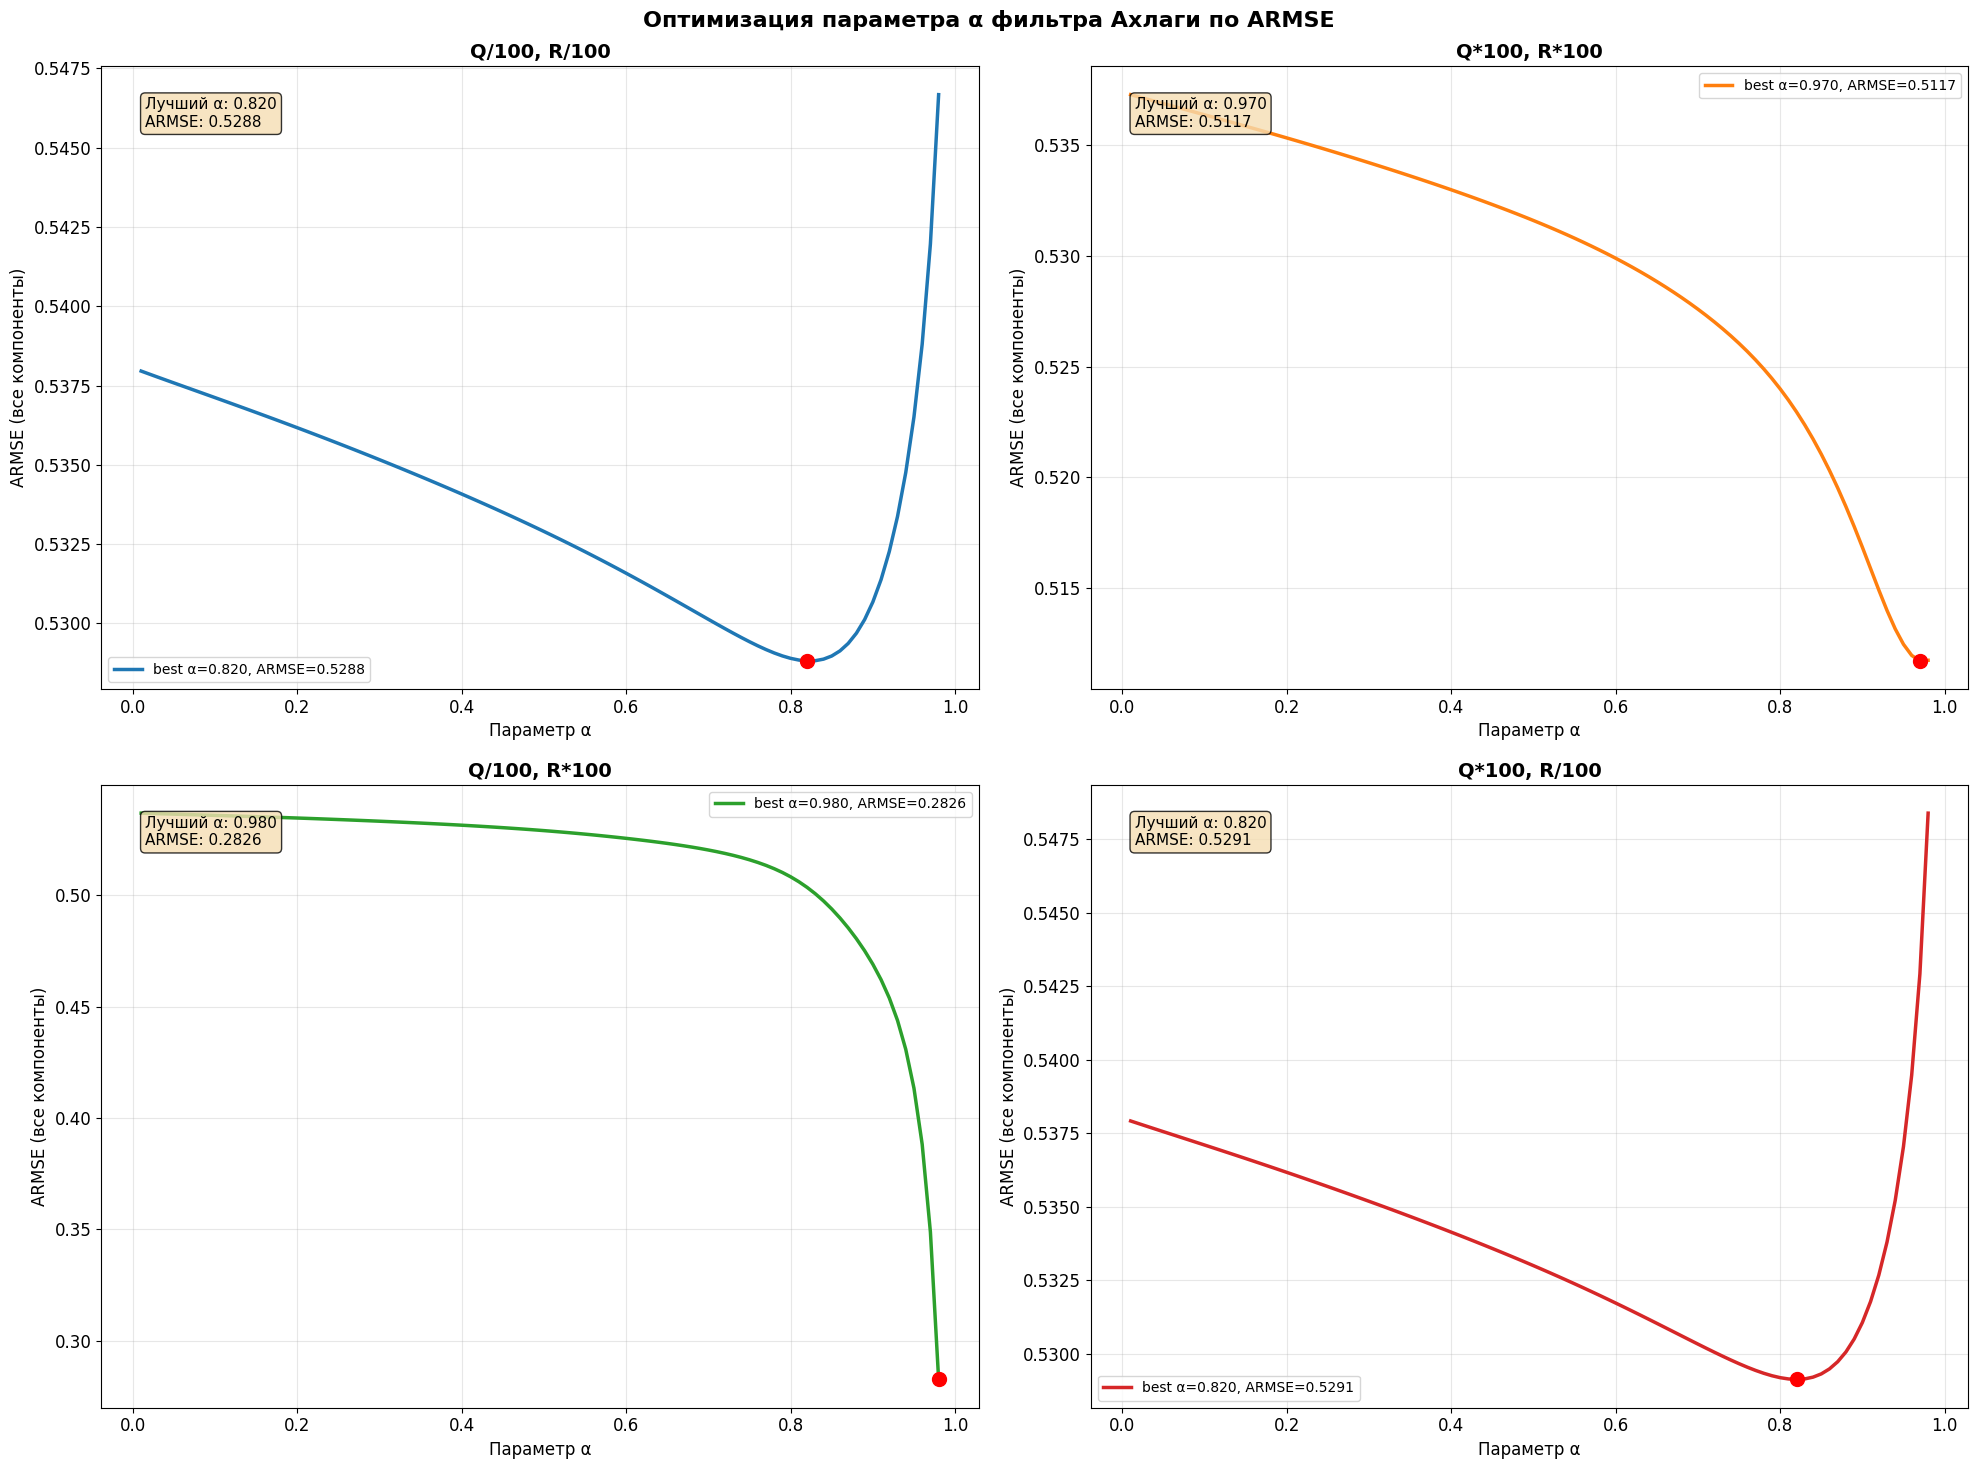


Лучшие значения α для фильтра Ахлаги (ARMSE):
   Q/100, R/100: α = 0.820
   Q*100, R*100: α = 0.970
   Q/100, R*100: α = 0.980
   Q*100, R/100: α = 0.820


In [ ]:
# Диапазон значений alpha (аналог b)
alpha_values = np.arange(0.01, 1.0, 0.01)[:-1]  # от 0.01 до 0.99
#alpha_values = np.arange(0.92, 1.0, 0.001)[:-1]  # от 0.01 до 0.99

# Количество запусков для усреднения
n_runs = 15
print(f'Количество запусков для каждого параметра: {n_runs}')

# Комбинации начальных приближений для Q и R
param_combinations = [
    ('Q/100, R/100',   Q / 100,   R / 100),
    ('Q*100, R*100',   Q * 100,   R * 100),
    ('Q/100, R*100',   Q / 100,   R * 100),
    ('Q*100, R/100',   Q * 100,   R / 100)
]

print(f'Суммарно: {n_runs * len(alpha_values)} * {len(param_combinations)}')

# Список для хранения лучших результатов в нужном формате
best_results = []

# Создаём фигуру с 4 субплотами
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten()

# Перебираем все комбинации
for idx, (label, Q0, R0) in enumerate(param_combinations):
    armse_list = []
    print(f"Обработка: {label}")

    for alpha in alpha_values:
        # Массив для хранения траекторий фильтра
        x_ahlagi = np.zeros((n_runs, N, dim_X))

        # Запускаем фильтр n_runs раз
        for i in range(n_runs):
            xf = Ahlagi_Zhou_Huang_filter(
                y_measure1[i],    # измерения
                x0,               # начальное состояние
                P0,               # начальная ковариация
                F,                # матрица перехода
                H,                # матрица наблюдения
                Q0,               # начальное Q
                R0,               # начальное R
                Ge,               # матрица шума процесса (Γ)
                alpha=alpha,      # текущее значение alpha
                Ksi_U=S_u,        # управляющее воздействие
                dt=dt             # шаг дискретизации
            )
            x_ahlagi[i] = xf

        # ARMSE по ВСЕМ компонентам
        #armse = calculate_ARMSE_n_dim(x_true[:n_runs, :, num_Xi], x_ahlagi[:, :, num_Xi])
        armse = calculate_ARMSE_n_dim(x_true[:n_runs, :, num_Xi], x_ahlagi[:, :, num_Xi])
        armse_list.append(armse)

    # Находим лучший alpha
    best_idx = np.argmin(armse_list)
    best_alpha = alpha_values[best_idx]
    best_armse = armse_list[best_idx]

    # Добавляем результат в список в нужном формате
    best_results.append({
        'case': label,
        'Q': Q0,
        'R': R0,
        'best_alpha': best_alpha
    })

    # Визуализация
    ax = axes[idx]
    ax.plot(alpha_values, armse_list, linewidth=2.5, color=f'C{idx}',
            label=f'best α={best_alpha:.3f}, ARMSE={best_armse:.4f}')
    ax.scatter(best_alpha, best_armse, color='red', s=100, zorder=5)

    ax.set_title(f'{label}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Параметр α', fontsize=12)
    ax.set_ylabel('ARMSE (все компоненты)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

    ax.text(0.05, 0.95,
            f'Лучший α: {best_alpha:.3f}\nARMSE: {best_armse:.4f}',
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Общий заголовок
fig.suptitle("Оптимизация параметра α фильтра Ахлаги по ARMSE",
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Вывод результатов
print("\n" + "="*70)
print("Лучшие значения α для фильтра Ахлаги (ARMSE):")
print("="*70)
for result in best_results:
    print(f"{result['case']:>15}: α = {result['best_alpha']:.3f}")

# Теперь best_results_antenna содержит данные в нужном формате:
# best_results_antenna = [
#     {'case': 'Q/100, R/100',  'Q': Q / 100,  'R': R / 100,  'best_alpha': 0.999},
#     {'case': 'Q*100, R*100',  'Q': Q * 100,  'R': R * 100,  'best_alpha': 0.999},
#     ...
# ]

## Фильтруем

### cases

In [ ]:
num_case = 0

# для 1 компоненты скорости (state)
best_results_speed = [
    {'case': 'Q/100, R/100',  'Q': Q / 100,  'R': R / 100,  'best_alpha': 0.870},
    {'case': 'Q*100, R*100',  'Q': Q * 100,  'R': R * 100,  'best_alpha': 0.980},
    {'case': 'Q/100, R*100',  'Q': Q / 100,  'R': R * 100,  'best_alpha': 0.730},
    {'case': 'Q*100, R/100',  'Q': Q * 100,  'R': R / 100,  'best_alpha': 0.760},
]

# для всех компонент (state)
best_results_speed = [
    {'case': 'Q;100, R;100',  'Q': Q / 100,  'R': R / 100,  'best_alpha': 0.998},
    {'case': 'Qx100, Rx100',  'Q': Q * 100,  'R': R * 100,  'best_alpha': 0.995},
    {'case': 'Q;100, Rx100',  'Q': Q / 100,  'R': R * 100,  'best_alpha': 0.947},
    {'case': 'Qx100, R;100',  'Q': Q * 100,  'R': R / 100,  'best_alpha': 0.959},
]

# для 1 компоненты скорости (true 6)
best_results_speed = [
    {'case': 'Q;100, R;100',  'Q': Q / 100,  'R': R / 100,  'best_alpha': 0.96},
    {'case': 'Qx100, Rx100',  'Q': Q * 100,  'R': R * 100,  'best_alpha': 0.98},
    {'case': 'Q;100, Rx100',  'Q': Q / 100,  'R': R * 100,  'best_alpha': 0.98},
    {'case': 'Qx100, R;100',  'Q': Q * 100,  'R': R / 100,  'best_alpha': 0.73},
]

Q_new = best_results_speed[num_case]['Q']
R_new = best_results_speed[num_case]['R']
best_alpha = best_results_speed[num_case]['best_alpha']
best_results = best_results_speed

In [ ]:
best_results_speed_v2 = [
    {'case': 'Q/100, R/100',  'Q': Q / 100,  'R': R / 100,  'best_alpha': 0.380},
    {'case': 'Q*100, R*100',  'Q': Q * 100,  'R': R * 100,  'best_alpha': 0.960},
    {'case': 'Q/100, R*100',  'Q': Q / 100,  'R': R * 100,  'best_alpha': 0.350},
    {'case': 'Q*100, R/100',  'Q': Q * 100,  'R': R / 100,  'best_alpha': 0.930},
]

In [ ]:
num_case = 0

best_results_antenna = [
    {'case': 'Q/100, R/100',  'Q': Q / 100,  'R': R / 100,  'best_alpha': 0.999},
    {'case': 'Q*100, R*100',  'Q': Q * 100,  'R': R * 100,  'best_alpha': 0.999},
    {'case': 'Q/100, R*100',  'Q': Q / 100,  'R': R * 100,  'best_alpha': 0.999},
    {'case': 'Q*100, R/100',  'Q': Q * 100,  'R': R / 100,  'best_alpha': 0.999},
]


#  для 1 компоненты (true 6)
best_results_antenna = [
    {'case': 'Q;1000, R;1000',  'Q': Q / 1000,  'R': R / 1000,  'best_alpha': 0.15},
    {'case': 'Qx10000, Rx10000',  'Q': Q * 1000,  'R': R * 1000,  'best_alpha': 0.12},
    {'case': 'Q;1000, Rx1000',  'Q': Q / 1000,  'R': R * 1000,  'best_alpha': 0.15},
    {'case': 'Qx1000, R;1000',  'Q': Q * 1000,  'R': R / 1000,  'best_alpha': 0.12},
]

#  для 1 компоненты (true 6)
best_results_antenna = [
    {'case': 'Q;100, R;100',  'Q': Q / 100,  'R': R / 100,  'best_alpha': 0.15},
    {'case': 'Qx100, Rx100',  'Q': Q * 100,  'R': R * 100,  'best_alpha': 0.14},
    {'case': 'Q;100, Rx100',  'Q': Q / 100,  'R': R * 100,  'best_alpha': 0.15},
    {'case': 'Qx100, R;100',  'Q': Q * 100,  'R': R / 100,  'best_alpha': 0.14},
]

Q_new = best_results_antenna[num_case]['Q']
R_new = best_results_antenna[num_case]['R']
best_alpha = best_results_antenna[num_case]['best_alpha']
best_results = best_results_antenna

In [ ]:
#QR 0.001 и 0.1 ANTENA

#  для 1 компоненты (true seq = 30)
best_results_antenna = [
    {'case': 'Q;100, R;100',  'Q': Q / 100,  'R': R / 100,  'best_alpha': 0.83},
    {'case': 'Qx100, Rx100',  'Q': Q * 100,  'R': R * 100,  'best_alpha': 0.98},
    {'case': 'Q;100, Rx100',  'Q': Q / 100,  'R': R * 100,  'best_alpha': 0.98},
    {'case': 'Qx100, R;100',  'Q': Q * 100,  'R': R / 100,  'best_alpha': 0.84},
]

Q_new = best_results_antenna[num_case]['Q']
R_new = best_results_antenna[num_case]['R']
best_alpha = best_results_antenna[num_case]['best_alpha']
best_results = best_results_antenna

In [ ]:
# SPEED - Version_measure_y

# N=300
# для 1 компоненты #1 (true seq = 30)

best_results_speed = [
    {'case': 'Q;100, R;100',  'Q': Q / 100,  'R': R / 100,  'best_alpha': 0.01},
    {'case': 'Qx100, Rx100',  'Q': Q * 100,  'R': R * 100,  'best_alpha': 0.01},
    {'case': 'Q;100, Rx100',  'Q': Q / 100,  'R': R * 100,  'best_alpha': 0.01},
    {'case': 'Qx100, R;100',  'Q': Q * 100,  'R': R / 100,  'best_alpha': 0.98},
]

Q_new = best_results_speed[num_case]['Q']
R_new = best_results_speed[num_case]['R']
best_alpha = best_results_speed[num_case]['best_alpha']
best_results = best_results_speed

### фильтр

In [ ]:
# ANTENA N=300 noise - 0.001, 0.01, R = 0.1
# для 1 компоненты state (n = 15)
best_results_antenna = [
    {'case': 'Q;100, R;100',  'Q': Q / 100,  'R': R / 100,  'best_alpha': 0.82},
    {'case': 'Qx100, Rx100',  'Q': Q * 100,  'R': R * 100,  'best_alpha': 0.97},
    {'case': 'Q;100, Rx100',  'Q': Q / 100,  'R': R * 100,  'best_alpha': 0.98},
    {'case': 'Qx100, R;100',  'Q': Q * 100,  'R': R / 100,  'best_alpha': 0.82},
]

Q_new = best_results_antenna[num_case]['Q']
R_new = best_results_antenna[num_case]['R']
best_alpha = best_results_antenna[num_case]['best_alpha']
best_results = best_results_antenna

In [ ]:
# Два фильтра

x_kalman = np.zeros((all_seq_s, N, dim_X))
x_ahlagi = np.zeros((all_seq_s, N, dim_X))

for i in range(all_seq_s):
  xf = Kalman_filter(y_measure1[i], x0, P0, F, H, Q_new, R_new, Ge=Ge, dt=dt, Ksi_U = S_u)
  x_kalman[i] = xf

for i in range(all_seq_s):
  xf = Ahlagi_Zhou_Huang_filter(y_measure1[i], x0, P0, F, H, Q_new, R_new, Ge, alpha=best_alpha, Ksi_U = S_u, dt = dt)
  x_ahlagi[i] = xf

print("\nARMSE Фильтр Калмана: ")
print_result_filt_ARMSE(x_true, x_noise, y_measure1, x_kalman, num_Xi, True)

print("\nARMSE Фильтр Ahlagi: ")
print_result_filt_ARMSE(x_true, x_noise, y_measure1, x_ahlagi, num_Xi, True)


ARMSE Фильтр Калмана: 
Компонента 0
Clear x & Filt x:                0.5694
State x & Filt x:               0.3131
Measure y x & Filt x:               0.0041
Все компоненты
Clear x & Filt x:                0.6236
State x & Filt x:               0.4212

ARMSE Фильтр Ahlagi: 
Компонента 0
Clear x & Filt x:                0.4838
State x & Filt x:               0.1270
Measure y x & Filt x:               0.2630
Все компоненты
Clear x & Filt x:                0.4845
State x & Filt x:               0.1826


(np.float64(0.4845006911069424), np.float64(0.18255236644382905))

## ENN

In [ ]:
# Формируем выборки
y_mc = y_measure1[:, 1:-1, 0]
y_ec1 = x_ahlagi[:, 1:-1, num_Xi]
y_ec2 = x_ahlagi[:, :-2, num_Xi]
y_ec = x_ahlagi[:, 2:, num_Xi]
y_c = x_true[:, 2:, num_Xi]
#y_c = y_measure1[:, 2:, 0]     #Ver_MEASURE

merge_model = np.stack([y_mc, y_ec1, y_ec2], axis=2)

y_c_ec = np.stack([y_c, y_ec], axis=2)

X_train, X_val, y_cec_train, y_cec_val = train_test_split(
    merge_model, y_c_ec, test_size=0.25, random_state=42, shuffle=False
)

e_train = y_cec_train[:,:,0]-y_cec_train[:,:,1]
e_val = y_cec_val[:,:,0]-y_cec_val[:,:,1]
e_train = e_train[:, :, np.newaxis]  # Форма (n, m, 1)
e_val = e_val[:, :, np.newaxis]    # Форма (k, p, 1)
print( e_train.shape, e_val.shape)


inputs = torch.FloatTensor(X_train) # batch_size, seq_len=300, input_size=3
targets = torch.FloatTensor(e_train) # Соответствующие выходы batch*300×1

val_inputs = torch.FloatTensor(X_val) # batch_size=32, seq_len=300, input_size=3
val_targets = torch.FloatTensor(e_val) # Соответствующие выходы batch*300×1

# Тест
x_sage_husa2 = np.zeros((all_seq_s2, N, dim_X))
for i in range(all_seq_s2):
  xf = Ahlagi_Zhou_Huang_filter(y_measure2[i], x0, P0, F, H, Q_new, R_new, Ge, alpha=best_alpha, Ksi_U = S_u, dt = dt)
  x_sage_husa2[i] = xf

y_mc2 = y_measure2[:, 1:-1, 0]
y_ec11 = x_sage_husa2[:, 1:-1, num_Xi]
y_ec22 = x_sage_husa2[:, :-2, num_Xi]
y_ec33 = x_sage_husa2[:, 2:, num_Xi]
y_c2 = x_true2[:, 2:, num_Xi]
#y_c2 = y_measure2[:, 2:, 0]     #Ver_MEASURE

# Объединение в массив (batch, 300, 3)
X_test2 = np.stack([y_mc2, y_ec11, y_ec22], axis=2)
y_c_ec2 = np.stack([y_c2, y_ec33], axis=2)
e_test2 = y_c_ec2[:,:,0]-y_c_ec2[:,:,1]
e_test2 = e_test2[:, :, np.newaxis]  # Форма (n, m, 1)
print(e_test2.shape)

(60, 298, 1) (20, 298, 1)
(20, 298, 1)


Best alpha:  0.82
Epoch [0/1000], Train Loss: 0.3236, Val Loss: 0.3668
Epoch [100/1000], Train Loss: 0.2233, Val Loss: 0.2489
Epoch [200/1000], Train Loss: 0.2203, Val Loss: 0.2463
Epoch [300/1000], Train Loss: 0.2127, Val Loss: 0.2348
Epoch [400/1000], Train Loss: 0.2169, Val Loss: 0.2350
Epoch [500/1000], Train Loss: 0.2211, Val Loss: 0.2441
Epoch [600/1000], Train Loss: 0.2146, Val Loss: 0.2396
Epoch [700/1000], Train Loss: 0.2109, Val Loss: 0.2342
Ранняя остановка на эпохе 757, лучший Val Loss: 0.2058
Обучение завершено. Лучший Val Loss: 0.2058
(M, N):

 (60, 298)
True Vs Measure y     0.5701951576061578
True Vs AKF         0.4821154392886136
True Vs ENN           0.4382658742544721
Measure y Vs AKF       0.26341310207511504
Measure y Vs ENN       0.28653473483102987

 (20, 298)
True Vs Measure y     0.5784648305376587
True Vs AKF         0.4928505899066097
True Vs ENN           0.45361392931338
Measure y Vs AKF       0.26534380857293477
Measure y Vs ENN       0.29147888270185124



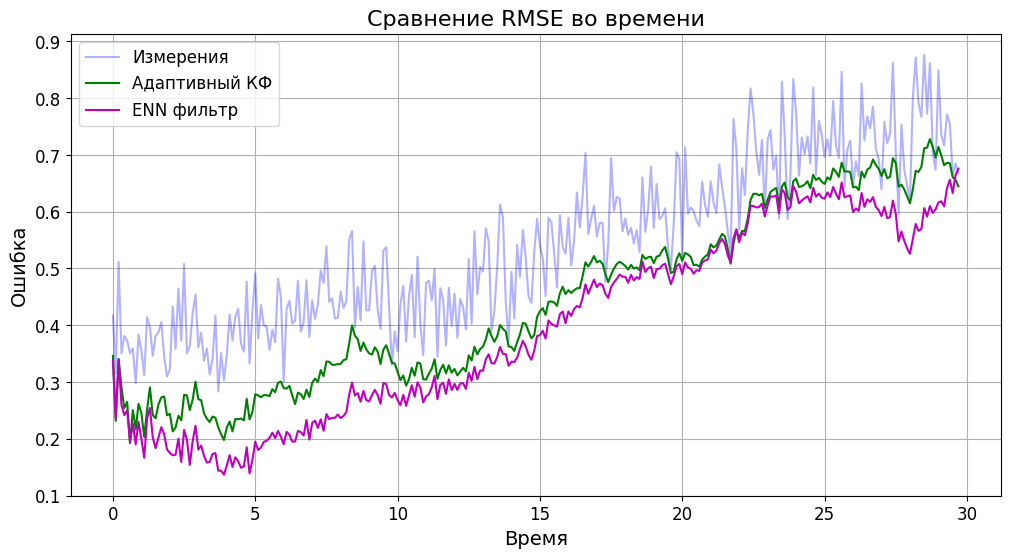

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Гиперпараметры
lr_cur = 0.001
hidden_size = 32 # Размер скрытого состояния
num_layers = 1    # Количество RNN-слоев
# +Алгоритм обучения

# Для ранней остановки
best_val_loss = float('inf')
best_model = None

epochs = 1000
patience = 300
input_size = 3    # Каждый входной вектор 3D

# Инициализация модели
model = SequenceRNN(input_size, hidden_size, num_layers)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr_cur)


print("Best alpha: ", best_alpha)
no_improve = 0

for epoch in range(epochs):
    # Обучение
    model.train()
    train_outputs = model(inputs)
    train_loss = criterion(train_outputs, targets)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # Валидация
    model.eval()
    with torch.no_grad():
        val_outputs = model(val_inputs)
        val_loss = criterion(val_outputs, val_targets)

    # Логирование
    if (epoch) % 100 == 0:
        print(f'Epoch [{epoch}/{epochs}], Train Loss: {train_loss.item():.4f}, Val Loss: {val_loss.item():.4f}')

    # Сохранение лучшей модели
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = deepcopy(model.state_dict())
        no_improve = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': best_model,
            'val_loss': best_val_loss,
            'train_loss': train_loss.item(),
        }, 'best_model.pth')
    else:
        no_improve += 1

    # Ранняя остановка
    if no_improve >= patience:
        print(f'Ранняя остановка на эпохе {epoch}, лучший Val Loss: {best_val_loss:.4f}')
        break

    if train_loss.item() < 0.002:
        print("Ошибка меньше заданного порога - окончание цикла обучения.")
        break

# Загрузка лучшей модели
model.load_state_dict(torch.load('best_model.pth')['model_state_dict'])
print(f'Обучение завершено. Лучший Val Loss: {best_val_loss:.4f}')


# Использование модели
model.eval()
predictions = model.predict(X_train)
print("(M, N):",)
x_enn, _, _ = result_enn_rmse(x_true, x_noise, y_measure1, x_ahlagi, predictions,
                        y_cec_train, Q_new, R_new, num_Xi)

pred_val = model.predict(X_val)
x_enn_val, _, _ = result_enn_rmse(x_true, x_noise, y_measure1, x_ahlagi, pred_val, y_cec_val,
                             Q_new, R_new, num_Xi, fl_train=False)

# Тестовая выборка:
pred_test2 = model.predict(X_test2)
y_enn_test, rmse_row1, rmse_row2 = result_enn_rmse(x_true2, x_noise2, y_measure2, x_sage_husa2,
                                  pred_test2, y_c_ec2, Q_new, R_new, num_Xi, fl_train=False)

meas_rmse_time = rmse_in_time(x_true2[:, 2:, num_Xi], y_measure2[:, 2:,0])
akf_rmse_time = rmse_in_time(x_true2[:, 2:, num_Xi], x_sage_husa2[:, 2:,num_Xi])
enn_rmse_time = rmse_in_time(x_true2[:, 2:, num_Xi], y_enn_test)

#akf_rmse_time = rmse_in_time(y_measure2[:, 2:, 0], x_sage_husa2[:, 2:,num_Xi])
#enn_rmse_time = rmse_in_time(y_measure2[:, 2:, 0], y_enn_test)

# График
time = np.arange(N-2) * dt
plt.figure(figsize=(12, 6))
plt.plot(time, meas_rmse_time, 'b', label='Измерения', alpha=0.3)
plt.plot(time, akf_rmse_time, 'g', label='Адаптивный КФ')
plt.plot(time, enn_rmse_time, 'm', label='ENN фильтр')
plt.title('Сравнение RMSE во времени')
plt.xlabel('Время')
plt.ylabel('Ошибка')
plt.grid(True)
plt.legend()

s =  best_results[num_case]['case'] + '_rmse, U=3, N=' + f'{N}'+'.jpg'
plt.savefig(s, dpi=150, bbox_inches='tight')  # JPEG формат

plt.show()
files.download(s)

In [ ]:
#!!!!!!!
#df_true = df_true.iloc[:-1]  # удаляем последнюю строку

In [ ]:
# Для df_true
s_qr = best_results[num_case]['case']

new_row = [s_qr] + rmse_row1 + [best_alpha, train_loss.item(), best_val_loss.item(), lr_cur, hidden_size]
df_true.loc[len(df_true)+1] = new_row

# Для df_measure
display(df_true)

,"Q, R",Измеренный y,Ahlagi,AKF+ENN,alpha,train_loss,val_loss,lr,hidden_size
1,"Q;100, R;100",0.561385,0.468472,0.430720,0.82,0.218438,0.209012,0.001,32
2,"Qx100, Rx100",0.561385,0.447918,0.364716,0.97,0.204344,0.141321,0.001,32
3,"Q;100, Rx100",0.561385,0.227498,0.150056,0.98,0.057863,0.034305,0.001,32
4,"Qx100, R;100",0.561385,0.469068,0.429102,0.82,0.219381,0.205766,0.001,32


In [ ]:
dim_X

2

## Пример

In [ ]:
id = 5 # номер последовательности в массиве из all_seq

y_true = x_true2[id, 2:, num_Xi]
y_m = y_measure2[id, 2:, 0]
x_akf = x_sage_husa2[id, 2:, num_Xi]
x_akf_enn = y_enn_test[id]

### speed

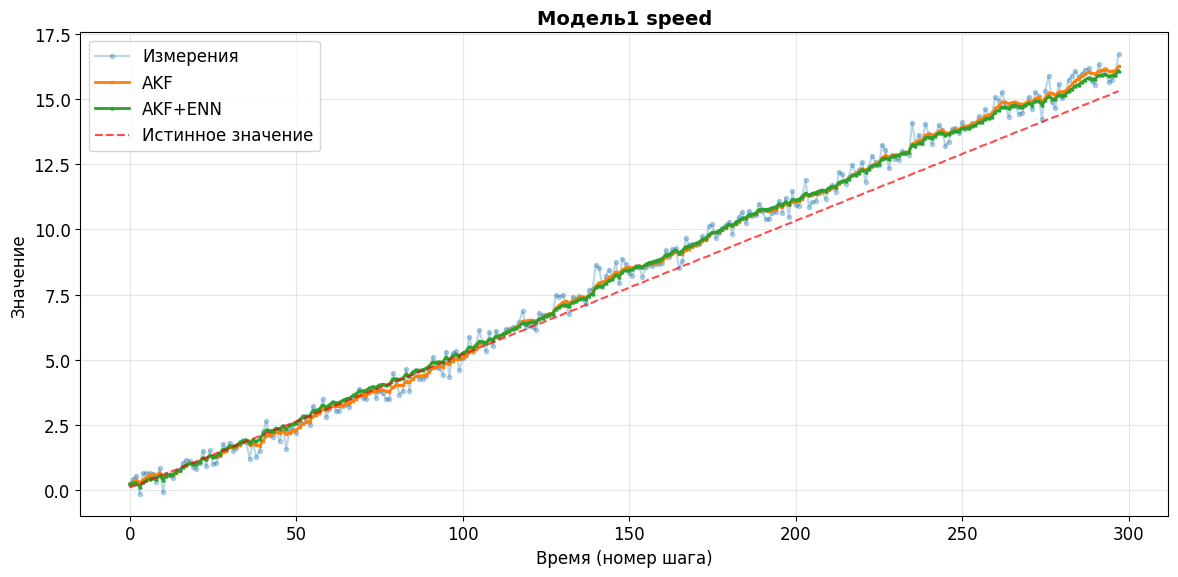

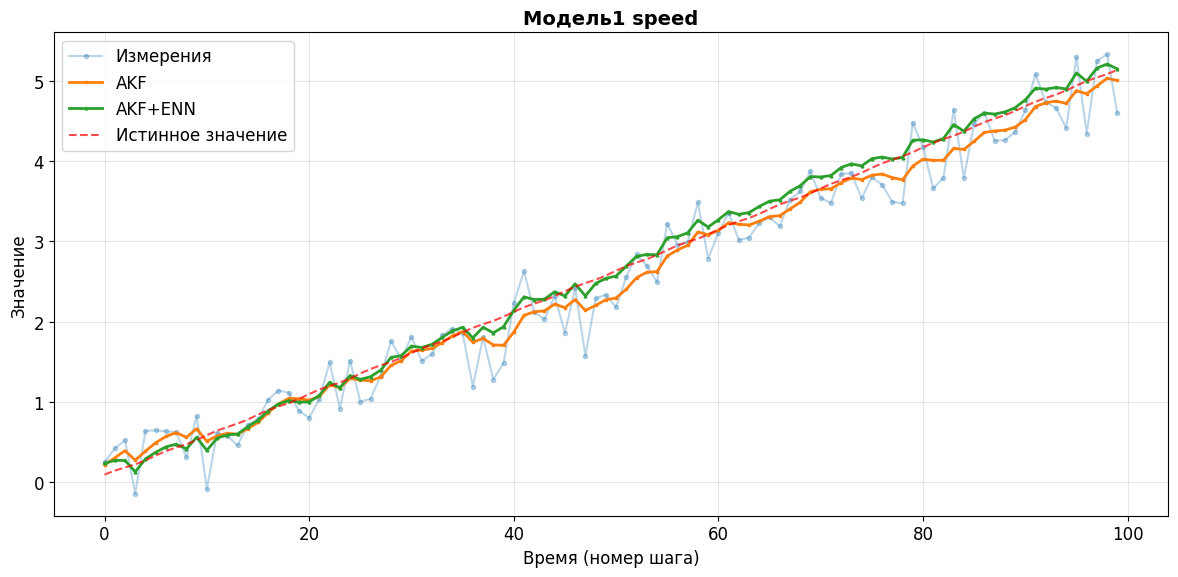

In [ ]:
plot_three_curves(y_true, y_m, x_akf, x_akf_enn, m=100, title = 'Модель1 speed')

### antena

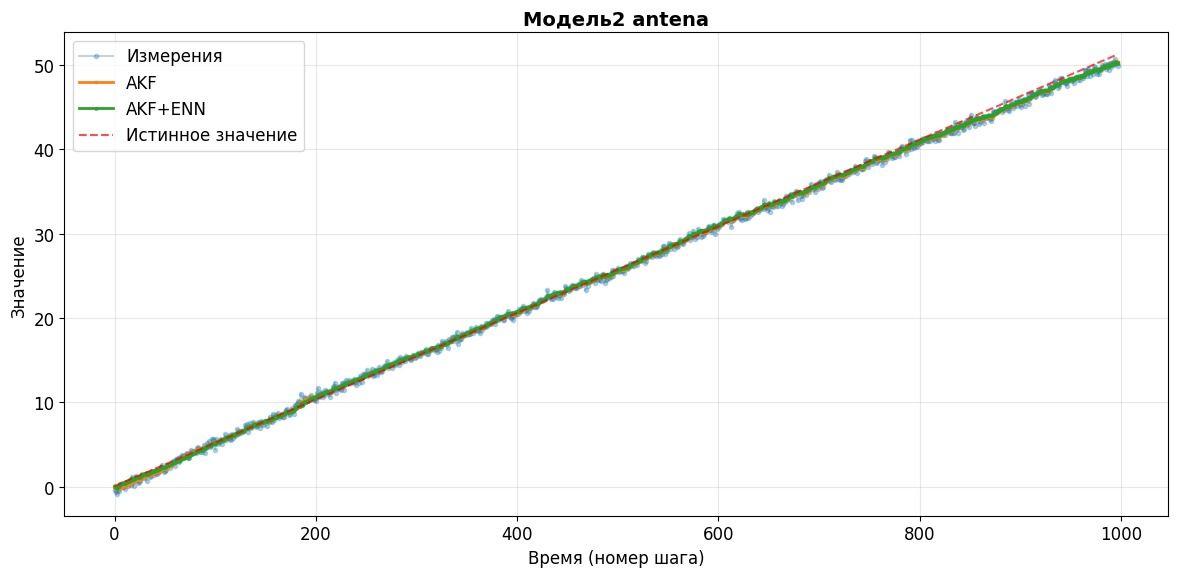

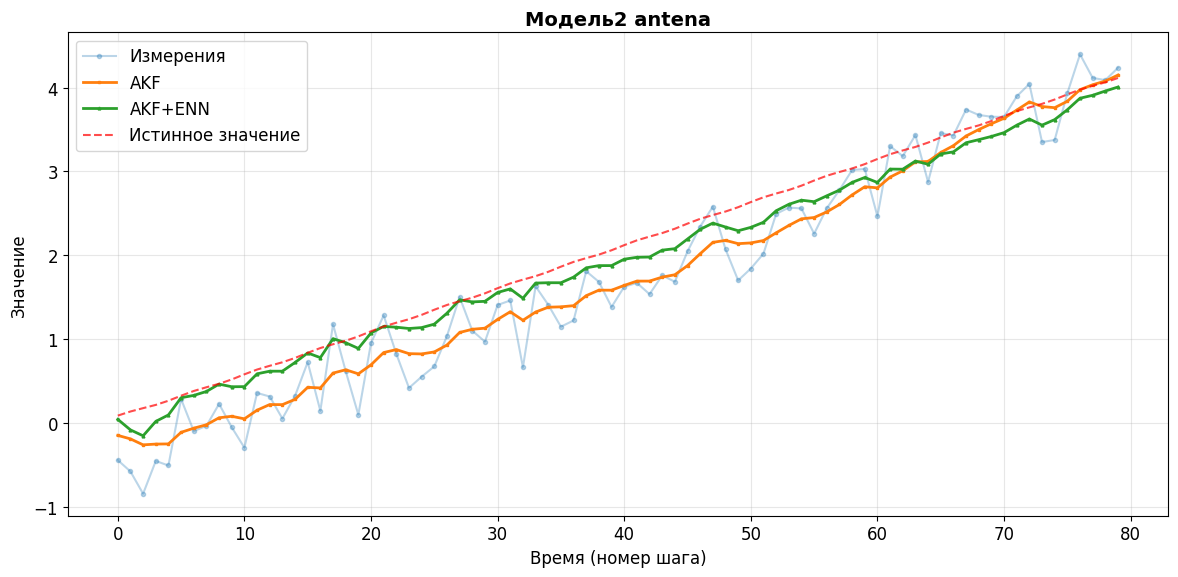

In [ ]:
plot_three_curves(y_true, y_m, x_akf, x_akf_enn, m=80, title = 'Модель2 antena')

## download

In [ ]:
# Импорт

# Сохраняем в файл (на виртуальной машине Colab)
df_true.to_excel(f"ANTENA N={N}, large QR.xlsx", index=False, engine='openpyxl')
# Скачиваем файл на компьютер
files.download(f"ANTENA N={N}, large QR.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>